### NEO Risk Analysis

**Course:** CPE-551

This notebook analyzes near-Earth asteroid data from NASA's NeoWs API and applies a custom risk scoring system that improves on NASA's binary hazardous/non-hazardous classification by weighting asteroid diameter, velocity, and miss distance into a graduated 0-10 score.

### 1. Imports, Setup and Data Load

In [3]:
import math
import json
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

from asteroid import Asteroid
from asteroid_tracker import AsteroidTracker
from functions import calculate_risk_score, normalize_value

plt.rcParams["figure.figsize"] = (10, 6)

try:
    tracker = AsteroidTracker("data/data.json")
    print(f"Loaded {len(tracker)} asteroids from data/data.json")
except FileNotFoundError as e:
    print(f"Data file not found: {e}")
    raise
except json.JSONDecodeError as e:
    print(f"Could not parse JSON: {e}")
    raise

Loaded 29 asteroids from data/data.json


### 2. Basic Stats

Total asteroid count, date range, NASA hazardous count, and risk-category breakdown. Along with showcasing the date span via `datetime`. Compute the number of days covered by the dataset using the standard library `datetime` module

In [4]:
stats = tracker.get_summary_stats()

print("Dataset Summary")
print("-" * 40)
print(f"Total asteroids:    {stats['total_count']}")
print(f"Date range:         {stats['date_range'][0]} to {stats['date_range'][1]}")
print(f"NASA hazardous:     {stats['hazardous_count']}")
print(f"Mean risk score:    {stats['mean_risk']:.2f} / 10")
print(f"Max risk score:     {stats['max_risk']:.2f} / 10")
print(f"Min risk score:     {stats['min_risk']:.2f} / 10")
print("\nRisk category counts:")
for category, count in stats["category_counts"].items():
    print(f"  {category:<10} {count}")
start_str, end_str = stats["date_range"]
start_dt = datetime.strptime(start_str, "%Y-%m-%d")
end_dt = datetime.strptime(end_str, "%Y-%m-%d")
span_days = (end_dt - start_dt).days + 1
print(f"Dataset spans {span_days} days ({start_str} to {end_str}).")

Dataset Summary
----------------------------------------
Total asteroids:    29
Date range:         2026-05-05 to 2026-05-12
NASA hazardous:     1
Mean risk score:    2.98 / 10
Max risk score:     8.03 / 10
Min risk score:     0.81 / 10

Risk category counts:
  Low        10
  Medium     18
  High       0
  Critical   1
Dataset spans 8 days (2026-05-05 to 2026-05-12).


### 3. Top 10 Riskiest Asteroids

`get_top_risks(n)` sorts the collection by computed risk score and returns the top `n`. Each `Asteroid` defines `__str__` for a readable one-line summary and `__gt__` so comparisons work directly on score.

In [5]:
top10 = tracker.get_top_risks(10)

for i, asteroid in enumerate(top10, start=1):
    print(f"{i:>2}. {asteroid}")

 1. Asteroid 318411 (2005 AH14) | Diameter: 1635.1m | Miss: 14065559.3 km | Risk: 8.03 (Critical)
 2. Asteroid (2015 KB57) | Diameter: 149.1m | Miss: 21218744.9 km | Risk: 4.86 (Medium)
 3. Asteroid 326290 Akhenaten (1998 HE3) | Diameter: 185.2m | Miss: 11003043.9 km | Risk: 4.39 (Medium)
 4. Asteroid (2004 XA45) | Diameter: 271.4m | Miss: 68753396.5 km | Risk: 3.94 (Medium)
 5. Asteroid (2002 VU114) | Diameter: 118.5m | Miss: 18962019.0 km | Risk: 3.89 (Medium)
 6. Asteroid (2018 JN1) | Diameter: 149.1m | Miss: 27056382.4 km | Risk: 3.84 (Medium)
 7. Asteroid (2010 KC) | Diameter: 62.7m | Miss: 62234661.0 km | Risk: 3.64 (Medium)
 8. Asteroid (2018 DB2) | Diameter: 162.8m | Miss: 19435434.4 km | Risk: 3.40 (Medium)
 9. Asteroid (2007 VV83) | Diameter: 49.4m | Miss: 17143471.6 km | Risk: 3.32 (Medium)
10. Asteroid (2007 HW4) | Diameter: 81.9m | Miss: 45182093.8 km | Risk: 3.28 (Medium)


### 4. Build a DataFrame for Plotting

Use a list comprehension to extract per-asteroid fields, then load them into a pandas `DataFrame`. This makes the plots in the next sections easy to produce.

In [6]:
rows = [
    {
        "name": a.name,
        "avg_diameter_m": (a.diameter_min + a.diameter_max) / 2,
        "velocity_kmh": a.velocity,
        "miss_distance_km": a.miss_distance,
        "is_hazardous": a.is_hazardous,
        "close_approach_date": a.close_approach_date,
        "risk_score": a.calculate_risk_score(),
        "risk_category": a.get_risk_category(),
    }
    for a in tracker.asteroids
]

df = pd.DataFrame(rows)
df.head()

,name,avg_diameter_m,velocity_kmh,miss_distance_km,is_hazardous,close_approach_date,risk_score,risk_category
0,318411 (2005 AH14),1635.093593,47205.373220,1.406556e+07,False,2026-05-12,8.033794,Critical
1,(2010 GZ33),142.410699,60612.418952,7.080954e+07,False,2026-05-12,2.075395,Low
2,(2010 JR34),12.403453,31261.444826,2.153152e+07,False,2026-05-12,3.256562,Medium
3,(2010 KC),62.739726,109323.726804,6.223466e+07,False,2026-05-12,3.642270,Medium
4,(2018 VB10),29.753812,26339.833435,1.971642e+07,False,2026-05-12,3.247252,Medium


### 5. Scatter Plot for Size vs Miss Distance

Plot the `avg_diameter_m` and `miss_distance_km` data from `DataFrame` in a Scatter Plot.

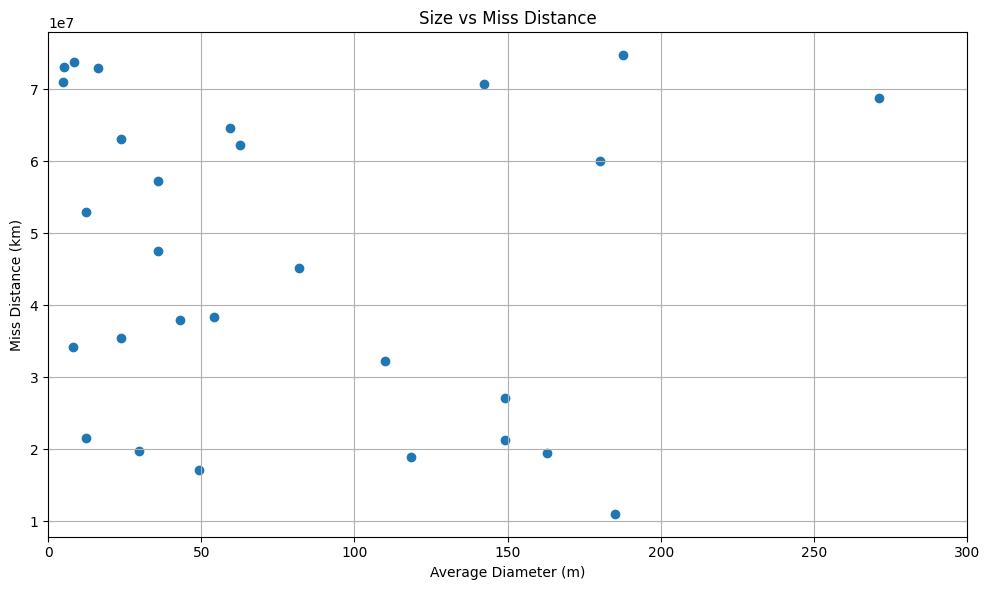

In [8]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df['avg_diameter_m'], 
    df['miss_distance_km']
)

plt.xlabel('Average Diameter (m)')
plt.ylabel('Miss Distance (km)')
plt.title('Size vs Miss Distance')
plt.grid(True)
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

### 6. Bar Chart: Threat Level Distribution

Display the distribution of asteroids across risk categories (`risk_category`: Low, Medium, High, Critical) using a Bar Chart.

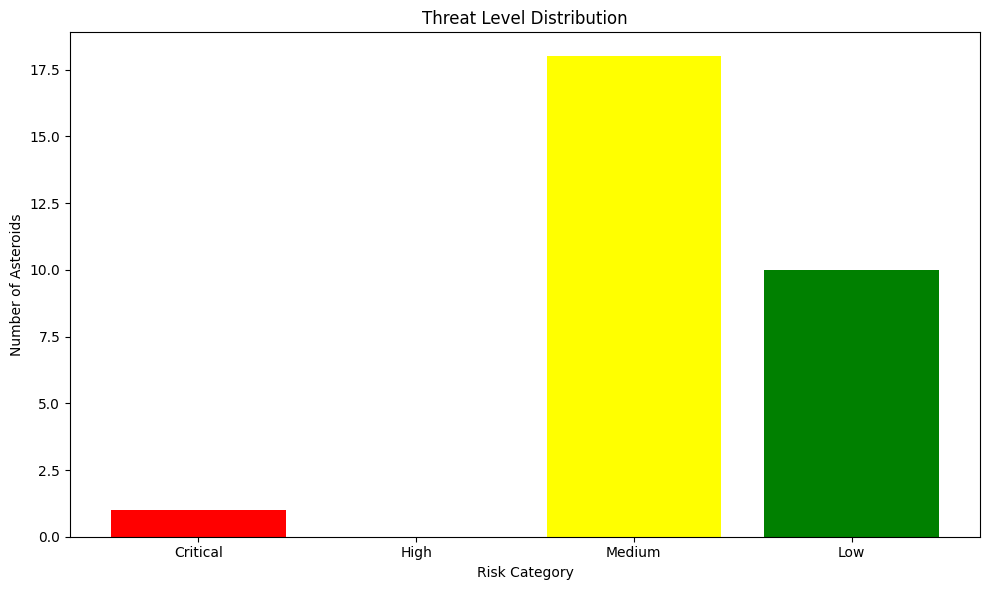

In [13]:
category_counts = df['risk_category'].value_counts()

category_order = ['Critical', 'High', 'Medium', 'Low']
colors = {'Critical': 'red', 'High': 'orange', 'Medium': 'yellow', 'Low': 'green'}
category_counts = category_counts.reindex(category_order)

plt.figure(figsize=(10, 6))
plt.bar(category_counts.index, category_counts.values, 
        color=[colors[cat] for cat in category_counts.index])
plt.xlabel('Risk Category')
plt.ylabel('Number of Asteroids')
plt.title('Threat Level Distribution')
plt.tight_layout()
plt.show()

### 7. Histogram: Risk Score Distribution

This histogram shows the distribution of `risk_score` across all the asteroids.